# 07. 注意機構と Transformer — トークンが互いを見る

## この章で分かること

- **埋め込み (embedding)**: トークンをベクトルにする
- **Query / Key / Value** と **スケール付きドット積注意** の数式と実装
- 注意行列が「どのトークンがどのトークンを見るか」を表すこと
- **マルチヘッド注意**・**位置エンコーディング**・**Transformer ブロック**
- 小さな文字レベル言語モデルで「次トークン予測」を体感する

RNN(06 章)は系列を逐次に処理しました。Transformer は再帰を捨て、
**系列内のすべてのトークン対の関係を一度に計算** します。
これが並列学習と長期依存の両立を可能にし、現代の LLM の基盤になりました。
この章はこの教材で最も重要な章です。

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import plotly.io as pio
import torch
import torch.nn as nn
import torch.nn.functional as F

from nn_textbook import datasets, plotting
from nn_textbook.metrics import softmax_np
from nn_textbook.training import get_device, set_seed

set_seed(0)
# Committed outputs use the CPU; set NN_TEXTBOOK_GPU=1 to run on the GPU.
device = get_device() if os.environ.get("NN_TEXTBOOK_GPU") == "1" else torch.device("cpu")
# Render Plotly both in JupyterLab and in the static Jupyter Book HTML.
pio.renderers.default = "plotly_mimetype+notebook_connected"
np.set_printoptions(precision=3, suppress=True)
print("device:", device)

device: cpu


## 1. Intuition — 注意は「重み付き検索」

注意機構は、各トークンが「他のどのトークンを参照すべきか」を学ぶ仕組みです。
データベース検索のアナロジーで考えます。

- **Query (Q)**: 「私はこういう情報が欲しい」という問い合わせ
- **Key (K)**: 各トークンの「私はこういう情報を持つ」という見出し
- **Value (V)**: 各トークンが実際に持つ中身

各 Query は全 Key との **類似度(ドット積)** を計算し、
softmax で重みにして、Value を重み付き平均します。
「関連するトークンの中身を、関連度に応じて混ぜて取り出す」操作です。

## 2. Definition — スケール付きドット積注意

入力を $Q \in \mathbb{R}^{T \times d_k}$, $K \in \mathbb{R}^{T \times d_k}$, $V \in \mathbb{R}^{T \times d_v}$ とすると:

$$
\mathrm{Attention}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V
$$

- $Q K^\top \in \mathbb{R}^{T \times T}$: **注意スコア行列**(全トークン対の類似度)
- $\sqrt{d_k}$ で割る: 次元が大きいとドット積が大きくなりすぎ、softmax が飽和するのを防ぐ
- softmax は行方向: 各 Query の重みの和が 1
- 結果 $\in \mathbb{R}^{T \times d_v}$: 各トークンの新しい表現

まず NumPy で一から実装し、shape を追います。

In [2]:
# Scaled dot-product attention from scratch.
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)   # (T, T)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)        # block forbidden positions
    attn = softmax_np(scores, axis=-1)               # (T, T), rows sum to 1
    out = attn @ V                                    # (T, d_v)
    return out, attn


rng = np.random.default_rng(0)
T, d_k, d_v = 4, 8, 8
Q = rng.standard_normal((T, d_k))
K = rng.standard_normal((T, d_k))
V = rng.standard_normal((T, d_v))
out, attn = scaled_dot_product_attention(Q, K, V)
print(f"Q,K: ({T},{d_k})  V: ({T},{d_v})")
print(f"attention matrix: {attn.shape}  (rows sum to 1: {np.allclose(attn.sum(1), 1)})")
print(f"output: {out.shape}")

Q,K: (4,8)  V: (4,8)
attention matrix: (4, 4)  (rows sum to 1: True)
output: (4, 8)


PyTorch の `F.scaled_dot_product_attention` と一致することを確認します。

In [3]:
# Our implementation matches PyTorch's built-in attention.
Qt, Kt, Vt = (torch.tensor(x).float() for x in (Q, K, V))
torch_out = F.scaled_dot_product_attention(Qt, Kt, Vt).numpy()
print("max abs diff vs torch:", np.abs(out - torch_out).max())

max abs diff vs torch: 7.66793548656608e-08


## 3. Visualization — 注意行列を読む

注意行列 $A_{ij}$ は「Query $i$ が Key $j$ をどれだけ見るか」。
意味のある例として、**埋め込みが似たトークンほど強く注意し合う** ことを見ます。

小さな語彙でトークン埋め込みを作り、QK 類似度行列を描きます。

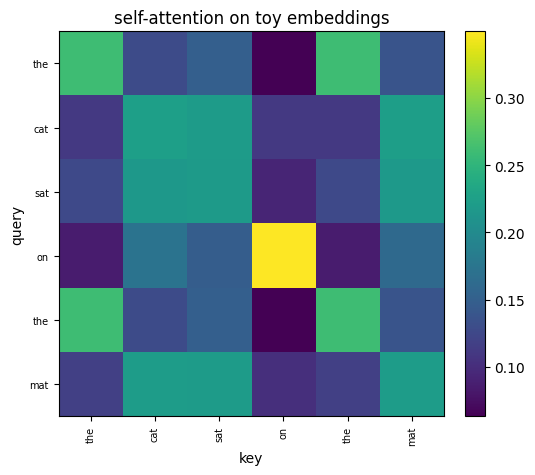

note: 'cat', 'sat', 'mat' (similar vectors) attend to each other


In [4]:
# Tokens with similar embeddings attend to each other (self-attention on embeddings).
tokens = ["the", "cat", "sat", "on", "the", "mat"]
vocab = {"the": [1.0, 0.0], "cat": [0.0, 1.0], "sat": [0.2, 0.9],
         "on": [-1.0, 0.0], "mat": [0.1, 1.0]}
E = np.array([vocab[t] for t in tokens])     # (6, 2) toy embeddings
E = E / np.linalg.norm(E, axis=1, keepdims=True)

_, attn = scaled_dot_product_attention(E, E, E)
plotting.plot_attention_heatmap(attn, tokens=tokens, title="self-attention on toy embeddings")
plt.show()
print("note: 'cat', 'sat', 'mat' (similar vectors) attend to each other")

### インタラクティブ: 注意の温度(JupyterLab のみ)

温度で注意の鋭さ(集中 vs 分散)を変えるデモです。静的 HTML では上の図を参照。

In [5]:
# Interactive (JupyterLab only): temperature sharpens or softens attention.
from nn_textbook.widgets import attention_matrix_explorer

attention_matrix_explorer(tokens, E)

interactive(children=(FloatSlider(value=1.0, description='temp', max=3.0, min=0.2), Output()), _dom_classes=('…

<function nn_textbook.widgets.attention_matrix_explorer.<locals>.draw(temperature)>

こちらは **静的 HTML でも動く** Plotly 版です(スライダーはブラウザ内 JS で動作)。
温度を下げると注意が一点集中(ほぼ one-hot)に、上げると一様に近づきます。

In [6]:
# Plotly version of the same demo: the slider works even in the exported HTML.
scores = E @ E.T / np.sqrt(E.shape[1])
fig = plotting.plotly_attention_slider(
    tokens, scores, temperatures=[0.2, 0.5, 1.0, 2.0, 3.0],
    title="attention vs softmax temperature",
)
fig.show()

## 4. 因果マスク — 未来を見ない注意

言語モデルでは、トークン $i$ は **自分より後ろ** を見てはいけません(カンニング防止)。
**因果マスク (causal mask)** で上三角を塞ぎ、注意を過去だけに限ります。

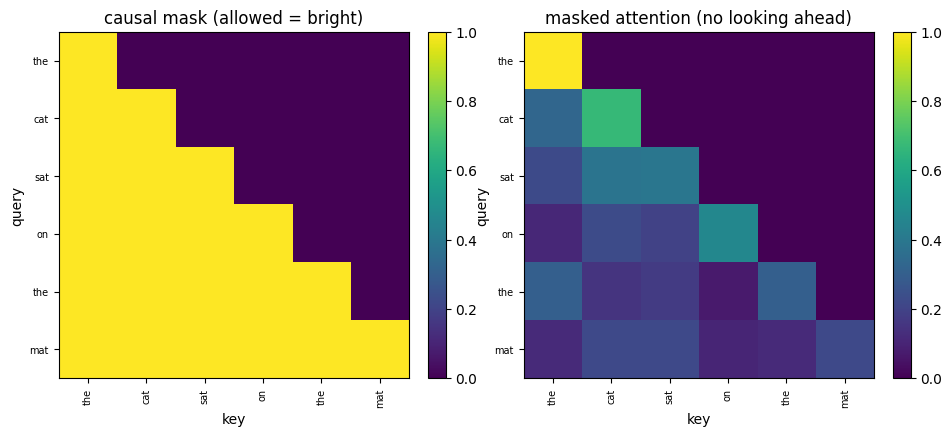

In [7]:
# Causal mask: token i may only attend to positions <= i (lower triangle).
T = 6
causal = np.tril(np.ones((T, T), dtype=bool))      # True = allowed
_, attn_masked = scaled_dot_product_attention(E, E, E, mask=causal)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plotting.plot_attention_heatmap(causal.astype(float), tokens=tokens, ax=axes[0], title="causal mask (allowed = bright)")
plotting.plot_attention_heatmap(attn_masked, tokens=tokens, ax=axes[1], title="masked attention (no looking ahead)")
plt.show()

## 5. Definition — マルチヘッド注意

1 つの注意では 1 種類の関係しか捉えられません。
**マルチヘッド注意** は、Q/K/V を $h$ 組の小さな部分空間に分け、
$h$ 個の注意を並列に計算して結合します。

$$
\mathrm{MultiHead}(Q,K,V) = \mathrm{Concat}(\mathrm{head}_1, \dots, \mathrm{head}_h)\, W^O
$$

各ヘッドが異なる関係(語順・係り受け・意味など)を学べます。
PyTorch の `nn.MultiheadAttention` で、ヘッドごとに違う注意パターンが出ることを見ます。

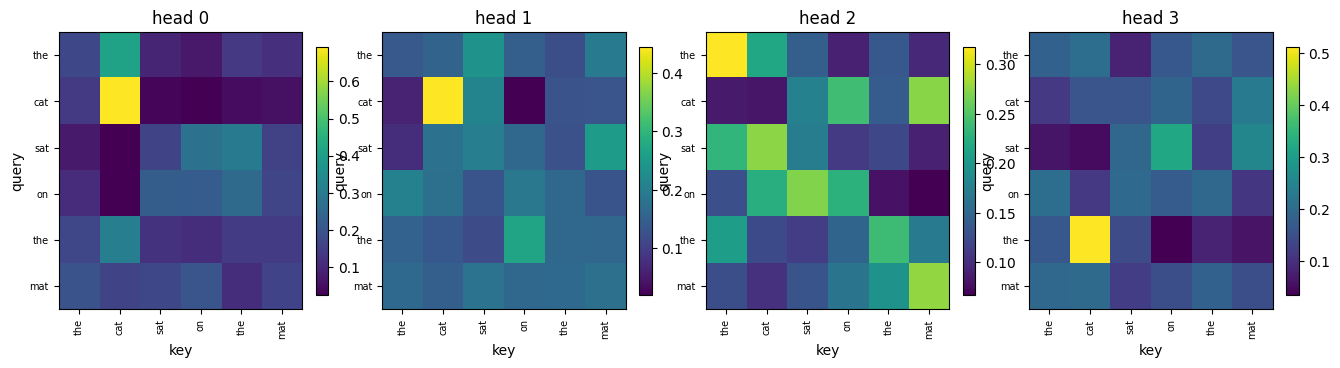

attention weights shape (batch, heads, T, T): (1, 4, 6, 6)


In [8]:
# Multi-head attention: different heads learn different attention patterns.
set_seed(0)
d_model, n_heads = 16, 4
mha = nn.MultiheadAttention(d_model, n_heads, batch_first=True)

seq = torch.randn(1, 6, d_model)
_, attn_weights = mha(seq, seq, seq, need_weights=True, average_attn_weights=False)
# attn_weights: (batch, n_heads, T, T)

fig, axes = plt.subplots(1, n_heads, figsize=(16, 3.6))
for head in range(n_heads):
    plotting.plot_attention_heatmap(attn_weights[0, head].detach().numpy(),
                                    tokens=tokens, ax=axes[head], title=f"head {head}")
plt.show()
print("attention weights shape (batch, heads, T, T):", tuple(attn_weights.shape))

## 6. 位置エンコーディング

注意は集合演算で、**トークンの順序を知りません**(Q,K,V の行を入れ替えても同じ)。
順序を与えるため、位置ごとに固有のベクトルを足します — **位置エンコーディング**。

$$
\mathrm{PE}_{(\text{pos}, 2i)} = \sin\!\left(\frac{\text{pos}}{10000^{2i/d}}\right), \qquad
\mathrm{PE}_{(\text{pos}, 2i+1)} = \cos\!\left(\frac{\text{pos}}{10000^{2i/d}}\right)
$$

異なる周波数の正弦波の組で、各位置に一意の「指紋」を与えます。

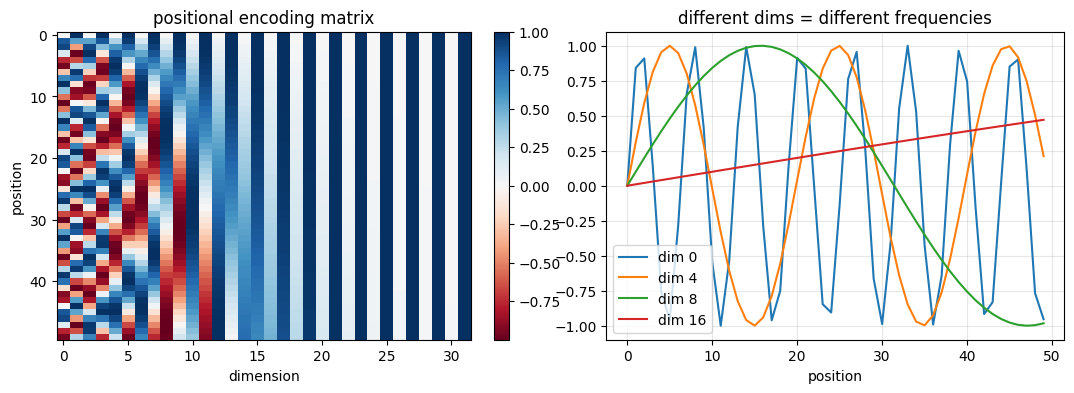

In [9]:
# Sinusoidal positional encodings: each position gets a unique multi-frequency code.
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.where(i % 2 == 0, np.sin(angle), np.cos(angle))
    return pe


pe = positional_encoding(50, 32)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
im = axes[0].imshow(pe, cmap="RdBu", aspect="auto")
axes[0].set_xlabel("dimension"); axes[0].set_ylabel("position"); axes[0].set_title("positional encoding matrix")
plt.colorbar(im, ax=axes[0], fraction=0.046)
for d in [0, 4, 8, 16]:
    axes[1].plot(pe[:, d], label=f"dim {d}")
axes[1].set_xlabel("position"); axes[1].set_title("different dims = different frequencies")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.show()

In [10]:
# Interactive (JupyterLab only): pick a dimension and see its frequency curve.
from nn_textbook.widgets import positional_encoding_explorer

positional_encoding_explorer(seq_len=50, d_model=32)

interactive(children=(IntSlider(value=0, description='dim', max=31), Output()), _dom_classes=('widget-interact…

<function nn_textbook.widgets.positional_encoding_explorer.<locals>.draw(dim)>

## 7. Transformer ブロックと小さな言語モデル

**Transformer ブロック** = 自己注意 + 位置ごとの MLP、それぞれに残差接続と LayerNorm。

$$
x \leftarrow x + \mathrm{Attention}(\mathrm{LN}(x)), \qquad
x \leftarrow x + \mathrm{MLP}(\mathrm{LN}(x))
$$

残差接続(04 章)と LayerNorm(04 章)がここで効いています。
まず単体のブロック(`nn_textbook.models.make_transformer_block`)で
入出力の shape と注意の重みを確認します。

In [11]:
# A single pre-norm transformer block: shapes in, shapes out, attention exposed.
from nn_textbook.models import make_transformer_block

set_seed(0)
block = make_transformer_block(d_model=64, n_heads=4, d_ff=256)
x_in = torch.randn(1, 6, 64)            # (batch, tokens, d_model)
x_out, attn_w = block(x_in)
print(f"input  : {tuple(x_in.shape)}   (batch, T, d_model)")
print(f"output : {tuple(x_out.shape)}   (same shape -> blocks can be stacked)")
print(f"attn   : {tuple(attn_w.shape)}   (batch, heads, query, key)")
print("attention rows sum to 1:", torch.allclose(attn_w.sum(-1), torch.ones(1, 4, 6)))

input  : (1, 6, 64)   (batch, T, d_model)
output : (1, 6, 64)   (same shape -> blocks can be stacked)
attn   : (1, 4, 6, 6)   (batch, heads, query, key)
attention rows sum to 1: True


入出力が同じ shape なので、ブロックはいくらでも **積み重ね** られます。
これを埋め込み + 位置エンコーディング + 出力射影で囲むと言語モデルになります。

内蔵ミニコーパスで **文字レベル言語モデル** を学習し、次の文字を予測させます。

In [12]:
# A tiny character-level transformer language model on the built-in corpus.
text = datasets.make_tiny_text_corpus(repeat=40)
tok = datasets.CharTokenizer(text)
data = torch.tensor(tok.encode(text))
print(f"corpus length: {len(text)} chars, vocab size: {tok.vocab_size}")


class TinyLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, n_layers=2, block_size=32):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=4 * d_model,
                                       dropout=0.0, batch_first=True, norm_first=True)
            for _ in range(n_layers)
        ])
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, idx):
        T = idx.shape[1]
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        # Causal mask, built on the same device as the input.
        mask = torch.triu(torch.full((T, T), float("-inf"), device=idx.device), diagonal=1)
        for blk in self.blocks:
            x = blk(x, src_mask=mask)
        return self.head(self.ln(x))


set_seed(0)
model = TinyLM(tok.vocab_size).to(device)
from nn_textbook.metrics import count_parameters
print("model parameters:", count_parameters(model))

corpus length: 12999 chars, vocab size: 25
model parameters: 105369


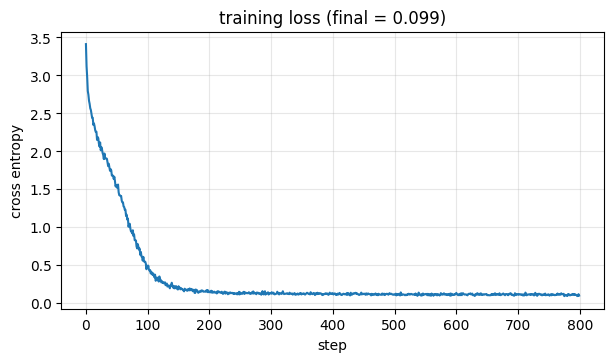

In [13]:
# Train the language model to predict the next character.
block_size = 32


def get_batch(data, batch_size=32):
    ix = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + 1 + block_size] for i in ix])
    return x, y


set_seed(0)
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
losses = []
for step in range(800):
    x, y = get_batch(data)
    x, y = x.to(device), y.to(device)
    logits = model(x)
    loss = F.cross_entropy(logits.reshape(-1, tok.vocab_size), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(losses); ax.set_xlabel("step"); ax.set_ylabel("cross entropy"); ax.grid(alpha=0.3)
ax.set_title(f"training loss (final = {losses[-1]:.3f})")
plt.show()

## 8. Visualization — 次トークンの確率分布

学習したモデルに文脈を与え、次の文字の確率分布を見ます。
モデルが「次に来そうな文字」に確率を集中できていれば学習成功です。

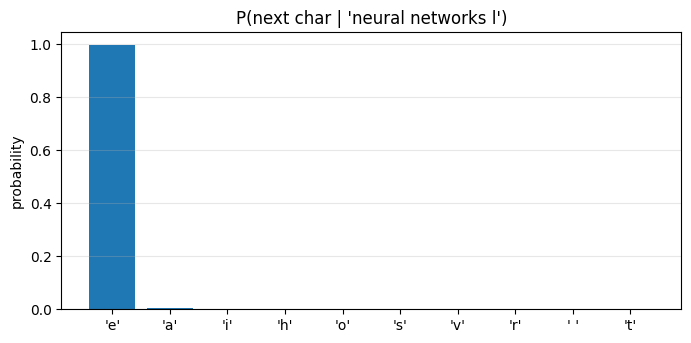

most likely next char: 'e'


In [14]:
# Next-character probability distribution given a context.
model.eval()
context = "neural networks l"
idx = torch.tensor(tok.encode(context))[None, -block_size:].to(device)
with torch.no_grad():
    logits = model(idx)
probs = F.softmax(logits[0, -1], dim=-1).cpu().numpy()

top = np.argsort(probs)[::-1][:10]
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar([repr(tok.itos[i]) for i in top], probs[top])
ax.set_title(f"P(next char | '{context}')"); ax.set_ylabel("probability")
ax.grid(alpha=0.3, axis="y")
plt.show()
print("most likely next char:", repr(tok.itos[top[0]]))

In [15]:
# Autoregressive generation: sample one character at a time.
def generate(model, start, n_new=120, temperature=0.8):
    model.eval()
    idx = torch.tensor(tok.encode(start))[None].to(device)
    for _ in range(n_new):
        logits = model(idx[:, -block_size:])
        probs = F.softmax(logits[0, -1] / temperature, dim=-1)
        nxt = torch.multinomial(probs, 1)
        idx = torch.cat([idx, nxt[None]], dim=1)
    return tok.decode(idx[0].tolist())


set_seed(0)
print(generate(model, "neural ", n_new=140))

neural networks learn representations from data. a network is a composition of linear and nonlinear transformations. gradients flow backward throug


ミニコーパスはごく小さいので、生成は学習文の断片の模倣になりますが、
**文字の繋がり・単語の形・空白の打ち方** を学べていることが分かります。
これを巨大コーパス・巨大モデルにスケールさせたものが GPT 系の言語モデルです(10 章)。

## 9. Failure Mode — 注意の弱点

- **計算量**: 注意は全トークン対を見るため、系列長 $T$ に対し $O(T^2)$。長文で重い。
- **位置情報**: 位置エンコーディングを忘れると順序を失う(語順が無意味になる)。
- **スケール**: $\sqrt{d_k}$ で割らないと softmax が飽和し、勾配が消える。

$O(T^2)$ を緩和する効率的注意(疎注意・線形注意・FlashAttention など)が活発に研究されています。

In [16]:
# Without the 1/sqrt(d_k) scaling, large d_k saturates softmax (near one-hot rows).
for d_k in [4, 64, 256]:
    Q = rng.standard_normal((4, d_k)); K = rng.standard_normal((4, d_k))
    unscaled = softmax_np(Q @ K.T, axis=-1)
    scaled = softmax_np(Q @ K.T / np.sqrt(d_k), axis=-1)
    print(f"d_k={d_k:>3}: max attn weight  unscaled={unscaled.max():.3f}  scaled={scaled.max():.3f}")

d_k=  4: max attn weight  unscaled=0.804  scaled=0.552
d_k= 64: max attn weight  unscaled=1.000  scaled=0.737
d_k=256: max attn weight  unscaled=1.000  scaled=0.566


## 10. Application — Transformer がもたらしたもの

Transformer は系列処理を一変させ、今や言語以外にも広がっています。

- 言語: GPT・BERT・T5、そして現代の LLM(10 章)
- 画像: Vision Transformer (ViT)
- 音声・タンパク質構造(AlphaFold)・マルチモーダル

鍵は **注意による全対全の関係づけ** と **並列学習可能性**。
「再帰を捨て、注意で繋ぐ」という発想が、大規模化への道を開きました。

## 11. まとめ

- attention = **Query と Key の類似度で Value を重み付き平均**(「重み付き検索」)。
- $\sqrt{d_k}$ スケーリングが softmax の飽和を防ぐ(ドット積の分散を 1 に揃える)。
- **因果マスク** で未来を遮断すると言語モデルになる。
- **マルチヘッド** は複数種類の関係を並列に学ぶ。順序の情報は **位置エンコーディング** で注入。
- Transformer ブロック = (LN →)attention + MLP、それぞれに残差接続。入出力同形なので積める。
- **次トークン予測** だけで文字の繋がり・単語の形が学べる — これをスケールしたのが LLM(10 章)。
- コストは $O(T^2)$ — コンテキスト長の制約の根源。

## 12. Exercises

1. `scaled_dot_product_attention` で、ある Query を他と大きく変え、
   注意行列の対応する行がどう変わるか観察せよ。
2. 因果マスクを外して言語モデルを学習すると損失がどうなるか(カンニングで下がる)確認せよ。
3. ヘッド数を 1 / 4 / 8 と変え、生成品質と注意パターンの多様性を比べよ。
4. 位置エンコーディングを足さずに学習し、生成がどう劣化するか観察せよ。
5. 生成の `temperature` を 0.2 / 0.8 / 1.5 と変え、出力の多様性の違いを述べよ。
6. (発展)`block_size`(文脈長)を 8 / 32 / 64 と変え、長期依存の学習にどう効くか調べよ。

## 13. Advanced Notes

**なぜ $\sqrt{d_k}$ で割るか(分散の議論)。** $Q, K$ の各成分が平均 0・分散 1 の独立なら、
ドット積 $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ の分散は $d_k$。標準偏差は $\sqrt{d_k}$ なので、
これで割るとスコアの分散が 1 に揃い、softmax が飽和しません(上のセルが実例)。

**自己注意 vs 交差注意。** Q,K,V が同じ系列由来なら **自己注意**(self-attention)、
Q が別系列(例: デコーダ)で K,V が入力系列なら **交差注意**(cross-attention)。
翻訳の encoder-decoder Transformer は両方を使います。

**Pre-LN vs Post-LN。** 元論文は Post-LN(残差の後に正規化)でしたが、深いモデルでは
**Pre-LN**(`norm_first=True`、正規化してから注意/MLP)が学習を安定させます。
本章の `TinyLM` も Pre-LN を使っています。学習率ウォームアップと併用するのが定番。

**計算量とコンテキスト長。** 注意は $O(T^2 d)$ の計算・$O(T^2)$ のメモリ。
これが LLM の「コンテキスト長」の制約の根源で、FlashAttention(メモリ効率化)、
疎・線形近似、状態空間モデル(Mamba 等)など、長文脈化の研究の出発点になっています。

**埋め込みと表現。** トークン埋め込みは「意味の似たトークンが近いベクトルになる」ように学習されます
(08 章の表現学習に繋がる)。学習済み埋め込みの幾何は、単語の意味的・統語的関係を反映します。